## **Ejercicio 1**

### Descripcion
*El dataset contiene información sobre los costumers. Uno de los atributos es ‘Churn’, que es nuestra variable target, la que queremos predecir.* 

*Churn nos dice si el customer dejó de usar el servicio o no en el último mes.*

*Nuestro objetivo es predecir este comportamiento de los customers para lograr retenerlos.*

In [54]:
import pandas as pd
df = pd.read_csv('info_customers.csv')
#df = pd.get_dummies(df)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [55]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Analisis Exploratorio

*analisis exploratorio ???*

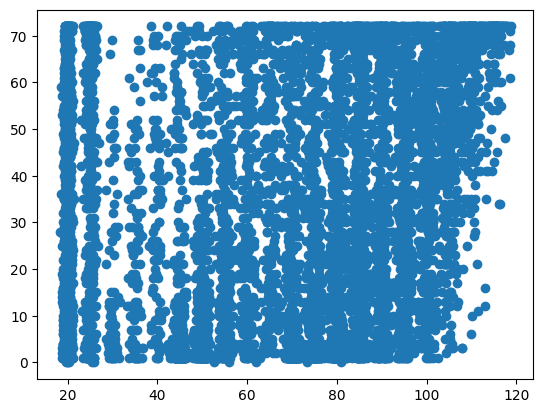

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(df['MonthlyCharges'], df['tenure'])
plt.show()

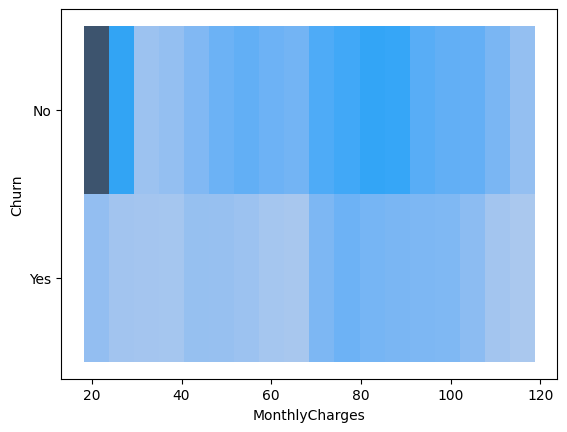

In [57]:
sns.histplot(data = df, x=df['MonthlyCharges'], y=df['Churn'])
plt.show()

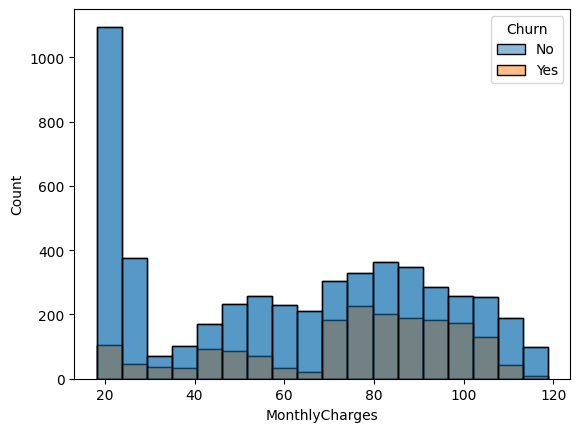

In [58]:
import numpy as np
import pandas as pd

import seaborn as sns

# Histogram
sns.histplot(x = df['MonthlyCharges'], hue = df['Churn'])

# Equivalent to:
sns.histplot(x = "MonthlyCharges", hue = "Churn", data = df)

plt.show()

### Algunas columnas no son reconocidas como numericas

*porque*

*solucion*

In [59]:
# Veo el tipo de dato
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [60]:
df["Churn"].head(10)

0     No
1     No
2    Yes
3     No
4    Yes
5    Yes
6     No
7     No
8    Yes
9     No
Name: Churn, dtype: str

 ## **Ejercicio 2**

*Antes de resolver el problema de los valores nulos, tengo que separar la muestra.*
*Si no, estaria haciendo Data Leakage. Porque estaria usando informacion del test para el training.*

In [61]:
# Separo Training, Validation y Test
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

# Training (60%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Validation (20%) y Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


## **Valores Faltantes**

*Tecnica + Justificacion*

In [62]:
# Convierto a valor numerico
df = df.apply(pd.to_numeric, errors="coerce") 
#df["Churn"] = pd.to_numeric(df["Churn"], errors="coerce")
df.dtypes

customerID          float64
gender              float64
SeniorCitizen         int64
Partner             float64
Dependents          float64
tenure                int64
PhoneService        float64
MultipleLines       float64
InternetService     float64
OnlineSecurity      float64
OnlineBackup        float64
DeviceProtection    float64
TechSupport         float64
StreamingTV         float64
StreamingMovies     float64
Contract            float64
PaperlessBilling    float64
PaymentMethod       float64
MonthlyCharges      float64
TotalCharges        float64
Churn               float64
dtype: object

In [70]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")
imputer.fit(X_train)
X_train = imputer.transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(X_test)

In [71]:
df["Churn"].head(10)

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: Churn, dtype: float64